In [1]:
import obstore
import os
import virtualizarr as vz
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry
import xarray as xr
import zarr

In [2]:
bucket = "s3://its-live-data"
key = "test-space/virtual-cubes"

In [3]:
granule_1 = "LC08_L1GT_020121_20231013_20231102_02_T2_X_LC09_L1GT_020121_20231106_20231106_02_T2_G0120V02_P084.nc"

In [4]:
store = obstore.store.from_url(bucket, region="us-west-2", skip_signature=True)
registry = ObjectStoreRegistry({bucket: store})
parser = HDFParser(drop_variables=["mapping", "img_pair_info"])

In [5]:
vds_1 = vz.open_virtual_dataset(
    url=os.path.join(bucket, key, granule_1),
    parser=parser,
    registry=registry,
    # load x/y/time as real, indexed coordinates: build_virtual_cube needs the
    # x/y *values* to compute the common grid, and combine_by_coords needs an
    # index on every dimension. Data variables stay virtual (ManifestArray).
    loadable_variables=["time", "y", "x"],
    decode_times=True,
)
vds_1

<xarray.Dataset> Size: 68MB
Dimensions:           (x: 2048, y: 2560, time: 1)
Coordinates:
  * x                 (x) float64 16kB -1.228e+05 -1.227e+05 ... 1.228e+05
  * y                 (y) float64 20kB -7.373e+05 -7.375e+05 ... -1.044e+06
  * time              (time) datetime64[ns] 8B 2023-10-25T16:52:38.576664832
Data variables:
    vx                (time, y, x) int16 10MB ManifestArray<shape=(1, 2560, 2...
    vy                (time, y, x) int16 10MB ManifestArray<shape=(1, 2560, 2...
    v                 (time, y, x) int16 10MB ManifestArray<shape=(1, 2560, 2...
    v_error           (time, y, x) int16 10MB ManifestArray<shape=(1, 2560, 2...
    chip_size_width   (time, y, x) uint16 10MB ManifestArray<shape=(1, 2560, ...
    chip_size_height  (time, y, x) uint16 10MB ManifestArray<shape=(1, 2560, ...
    interp_mask       (time, y, x) uint8 5MB ManifestArray<shape=(1, 2560, 20...
Attributes: (12/14)
    GDAL_AREA_OR_POINT:         Area
    Conventions:                CF-1.8
    date_created:               27-Aug-2024 00:29:36
    title:                      autoRIFT surface velocities
    autoRIFT_software_version:  1.5.0
    autoRIFT_parameter_file:    http://its-live-data.s3.amazonaws.com/autorif...
    ...                         ...
    motion_detection_method:    feature
    motion_coordinates:         map
    author:                     Alex S. Gardner, JPL/NASA; Yang Lei, GPS/Caltech
    institution:                NASA Jet Propulsion Laboratory (JPL), Califor...
    source:                     NASA MEaSUREs ITS_LIVE project. Processed by ...
    references:                 When using this data, please acknowledge the ...

In [6]:
granule_2 = "LC08_L1GT_020120_20201121_20210315_02_T2_X_LC08_L1GT_020120_20210124_20210305_02_T2_G0120V02_P051.nc"

In [7]:
vds_2 = vz.open_virtual_dataset(
    url=os.path.join(bucket, key, granule_2),
    parser=parser,
    registry=registry,
    loadable_variables=["time", "y", "x"],
    decode_times=True,
)
vds_2

<xarray.Dataset> Size: 68MB
Dimensions:           (x: 2560, y: 2048, time: 1)
Coordinates:
  * x                 (x) float64 20kB -3.071e+05 -3.07e+05 ... -187.5 -67.5
  * y                 (y) float64 16kB -7.988e+05 -7.989e+05 ... -1.044e+06
  * time              (time) datetime64[ns] 8B 2020-12-23T16:52:18.221675008
Data variables:
    vx                (time, y, x) int16 10MB ManifestArray<shape=(1, 2048, 2...
    vy                (time, y, x) int16 10MB ManifestArray<shape=(1, 2048, 2...
    v                 (time, y, x) int16 10MB ManifestArray<shape=(1, 2048, 2...
    v_error           (time, y, x) int16 10MB ManifestArray<shape=(1, 2048, 2...
    chip_size_width   (time, y, x) uint16 10MB ManifestArray<shape=(1, 2048, ...
    chip_size_height  (time, y, x) uint16 10MB ManifestArray<shape=(1, 2048, ...
    interp_mask       (time, y, x) uint8 5MB ManifestArray<shape=(1, 2048, 25...
Attributes: (12/15)
    GDAL_AREA_OR_POINT:         Area
    Conventions:                CF-1.8
    date_created:               17-Dec-2022 00:01:37
    title:                      autoRIFT surface velocities
    autoRIFT_software_version:  1.5.0
    autoRIFT_parameter_file:    http://its-live-data.s3.amazonaws.com/autorif...
    ...                         ...
    motion_coordinates:         map
    author:                     Alex S. Gardner, JPL/NASA; Yang Lei, GPS/Caltech
    institution:                NASA Jet Propulsion Laboratory (JPL), Califor...
    source:                     NASA MEaSUREs ITS_LIVE project. Processed by ...
    references:                 When using this data, please acknowledge the ...
    date_updated:               15-Aug-2023 17:58:25

In [8]:
import numpy as np

from virtualizarr.manifests import ChunkManifest, ManifestArray
from virtualizarr.manifests.manifest import MISSING_CHUNK_PATH
from virtualizarr.manifests.utils import copy_and_replace_metadata


def pad_manifestarray(marr, new_shape, offsets=None):
    """Smart padding: place a ManifestArray into a larger `new_shape` at the
    given per-axis element `offsets`, filling every other chunk-grid cell with
    nodata chunks (ChunkEntry path="", which reads back as the array's fill
    value). Only chunk references are moved -- no pixel data is read.

    Parameters
    ----------
    marr : ManifestArray
        The array to place. Its existing chunk references are preserved.
    new_shape : sequence of int
        Target shape (same ndim as `marr`, >= its shape on every axis).
    offsets : sequence of int, optional
        Element offset of `marr`'s origin within `new_shape` on each axis.
        Defaults to 0 everywhere (top-left). Each offset must be a multiple of
        that axis' chunk size, and a partial final chunk is only allowed if the
        data reaches the grid edge -- so granules tile without overlapping
        partial chunks.
    """
    new_shape = tuple(int(s) for s in new_shape)
    if offsets is None:
        offsets = (0,) * len(new_shape)
    offsets = tuple(int(o) for o in offsets)
    shape, chunks = marr.shape, marr.chunks

    if len(new_shape) != len(shape):
        raise ValueError(f"new_shape {new_shape} ndim != array ndim {len(shape)}")
    for ax, (off, s, c, n) in enumerate(zip(offsets, shape, chunks, new_shape)):
        if off % c != 0:
            raise ValueError(f"axis {ax}: offset {off} not a multiple of chunk size {c}")
        if off + s > n:
            raise ValueError(f"axis {ax}: offset {off}+size {s} exceeds new size {n}")
        if s % c != 0 and off + s != n:
            raise ValueError(
                f"axis {ax}: size {s} is not a multiple of chunk {c} and does not "
                f"reach the grid edge ({off}+{s} != {n}); cannot tile cleanly"
            )

    old_grid = marr.manifest.shape_chunk_grid
    new_grid = tuple(-(-s // c) for s, c in zip(new_shape, chunks))
    chunk_offsets = [o // c for o, c in zip(offsets, chunks)]

    # build the new chunk-grid arrays, initialised to the nodata sentinel,
    # then drop the existing references in at the chunk offset
    new_paths = np.full(new_grid, MISSING_CHUNK_PATH, dtype=np.dtypes.StringDType())
    new_offsets = np.zeros(new_grid, dtype="uint64")
    new_lengths = np.zeros(new_grid, dtype="uint64")
    region = tuple(slice(co, co + og) for co, og in zip(chunk_offsets, old_grid))
    new_paths[region] = marr.manifest._paths
    new_offsets[region] = marr.manifest._offsets
    new_lengths[region] = marr.manifest._lengths

    new_manifest = ChunkManifest.from_arrays(
        paths=new_paths, offsets=new_offsets, lengths=new_lengths,
        validate_paths=False,  # existing paths already valid, new ones are sentinel
        inlined=marr.manifest._inlined or None,
    )
    new_metadata = copy_and_replace_metadata(marr.metadata, new_shape=list(new_shape))
    return ManifestArray(metadata=new_metadata, chunkmanifest=new_manifest)

In [9]:
def _union_axis(starts, ends, step):
    """Regular coordinate vector covering [starts..ends] at spacing `step`."""
    if step > 0:
        lo, hi = min(starts), max(ends)
    else:
        lo, hi = max(starts), min(ends)
    n = round((hi - lo) / step) + 1
    return lo + np.arange(n) * step


def extend_coords(vds_list):
    """Compute the common (union) x/y coordinate vectors covering all granules,
    plus each granule's per-axis element offset into that grid.

    The granules' x/y coordinates must be loaded (real values) and share a
    common posting and lattice. Returns ``(x_union, y_union, offsets)`` where
    ``offsets[i]`` is ``{"x": ix, "y": iy}`` for granule ``i``.

    ``time`` is not extended here -- each granule keeps its own time value and
    ``combine_by_coords`` stacks/orders them along the time dimension.
    """
    xs = [vds["x"].values for vds in vds_list]
    ys = [vds["y"].values for vds in vds_list]
    dx = float(xs[0][1] - xs[0][0])
    dy = float(ys[0][1] - ys[0][0])
    for x, y in zip(xs, ys):
        if not (np.isclose(x[1] - x[0], dx) and np.isclose(y[1] - y[0], dy)):
            raise ValueError("all datasets must share the same x/y posting")

    x_union = _union_axis([x[0] for x in xs], [x[-1] for x in xs], dx)
    y_union = _union_axis([y[0] for y in ys], [y[-1] for y in ys], dy)
    offsets = [
        {"x": round((x[0] - x_union[0]) / dx), "y": round((y[0] - y_union[0]) / dy)}
        for x, y in zip(xs, ys)
    ]
    return x_union, y_union, offsets

In [10]:
def build_virtual_cube(vds_list):
    """Mosaic virtual datasets onto their common x/y grid and stack along time.

    Three steps:
      1. ``extend_coords``    -> union x/y grid + each granule's offset into it
      2. ``pad_manifestarray``-> drop each granule's data at its offset on the
                                 union grid (nodata everywhere else)
      3. ``combine_by_coords``-> order/stack the granules along time

    Data variables stay virtual (ManifestArray); x/y/time are real, indexed
    coordinates. No pixel data is read.
    """
    x_union, y_union, offsets = extend_coords(vds_list)
    sizes = {"x": len(x_union), "y": len(y_union)}

    placed = []
    for vds, off in zip(vds_list, offsets):
        new_vars = {}
        for name, var in vds.data_vars.items():
            data = var.data
            if isinstance(data, ManifestArray):
                new_shape = [sizes.get(str(d), s) for d, s in zip(var.dims, data.shape)]
                var_offsets = [off.get(str(d), 0) for d in var.dims]
                data = pad_manifestarray(data, new_shape, var_offsets)
            new_vars[name] = xr.Variable(var.dims, data, attrs=var.attrs, encoding=var.encoding)
        placed.append(xr.Dataset(
            new_vars,
            coords={"x": ("x", x_union), "y": ("y", y_union), "time": vds["time"]},
            attrs=vds.attrs,
        ))

    return xr.combine_by_coords(
        placed, coords="minimal", compat="override", join="override",
        combine_attrs="drop_conflicts",
    )

In [11]:
# mosaic both granules onto their common grid and stack along time
cube = build_virtual_cube([vds_1, vds_2])
cube

<xarray.Dataset> Size: 239MB
Dimensions:           (time: 2, y: 2560, x: 3584)
Coordinates:
  * time              (time) datetime64[ns] 16B 2020-12-23T16:52:18.221675008...
  * y                 (y) float64 20kB -7.373e+05 -7.375e+05 ... -1.044e+06
  * x                 (x) float64 29kB -3.071e+05 -3.07e+05 ... 1.228e+05
Data variables:
    vx                (time, y, x) int16 37MB ManifestArray<shape=(2, 2560, 3...
    vy                (time, y, x) int16 37MB ManifestArray<shape=(2, 2560, 3...
    v                 (time, y, x) int16 37MB ManifestArray<shape=(2, 2560, 3...
    v_error           (time, y, x) int16 37MB ManifestArray<shape=(2, 2560, 3...
    chip_size_width   (time, y, x) uint16 37MB ManifestArray<shape=(2, 2560, ...
    chip_size_height  (time, y, x) uint16 37MB ManifestArray<shape=(2, 2560, ...
    interp_mask       (time, y, x) uint8 18MB ManifestArray<shape=(2, 2560, 3...
Attributes:
    GDAL_AREA_OR_POINT:         Area
    Conventions:                CF-1.8
    title:                      autoRIFT surface velocities
    autoRIFT_software_version:  1.5.0
    autoRIFT_parameter_file:    http://its-live-data.s3.amazonaws.com/autorif...
    scene_pair_type:            optical
    motion_detection_method:    feature
    motion_coordinates:         map
    author:                     Alex S. Gardner, JPL/NASA; Yang Lei, GPS/Caltech
    institution:                NASA Jet Propulsion Laboratory (JPL), Califor...
    references:                 When using this data, please acknowledge the ...
    date_updated:               15-Aug-2023 17:58:25

In [12]:
import shutil

import icechunk as ic

# the referenced chunk data lives on this public, anonymous S3 bucket
url_prefix = "s3://its-live-data/"
store_path = "its_live_cube.icechunk"

# start fresh so this cell is re-runnable
shutil.rmtree(store_path, ignore_errors=True)

# register a virtual chunk container so icechunk knows how to read the s3 refs
config = ic.RepositoryConfig.default()
config.set_virtual_chunk_container(
    ic.VirtualChunkContainer(url_prefix, ic.s3_store(region="us-west-2", anonymous=True))
)
repo = ic.Repository.create(
    storage=ic.local_filesystem_storage(store_path),
    config=config,
    authorize_virtual_chunk_access=ic.containers_credentials(
        {url_prefix: ic.s3_credentials(anonymous=True)}
    ),
)


# icechunk metadata is strict JSON and cannot represent NaN/inf, but ITS_LIVE
# stores NaN in some attributes (e.g. 'stable_shift_stationary'); drop those.
def _drop_nonfinite_attrs(ds):
    ds = ds.copy()

    def clean(attrs):
        keep = {}
        for k, v in attrs.items():
            arr = np.asarray(v)
            if arr.dtype.kind == "f" and not np.isfinite(arr).all():
                continue
            keep[k] = v
        return keep

    ds.attrs = clean(ds.attrs)
    for var in ds.variables.values():
        var.attrs = clean(var.attrs)
    return ds


# write the cube: only the virtual references are stored, no pixel data is copied
session = repo.writable_session("main")
_drop_nonfinite_attrs(cube).vz.to_icechunk(session.store)
snapshot_id = session.commit("its_live virtual cube: 2 granules mosaicked + stacked on time")
print("committed snapshot", snapshot_id)

# reopen from the committed store
cube_roundtrip = xr.open_zarr(repo.readonly_session("main").store, consolidated=False, zarr_format=3)
cube_roundtrip

  2026-06-18T23:05:44.972318Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

committed snapshot 6YRDRYXZXE9TKK0ABNEG


<xarray.Dataset> Size: 514MB
Dimensions:           (time: 2, y: 2560, x: 3584)
Coordinates:
  * time              (time) datetime64[ns] 16B 2020-12-23T16:52:18.221675008...
  * y                 (y) float64 20kB -7.373e+05 -7.375e+05 ... -1.044e+06
  * x                 (x) float64 29kB -3.071e+05 -3.07e+05 ... 1.228e+05
Data variables:
    interp_mask       (time, y, x) float32 73MB ...
    vx                (time, y, x) float32 73MB ...
    chip_size_width   (time, y, x) float32 73MB ...
    v_error           (time, y, x) float32 73MB ...
    vy                (time, y, x) float32 73MB ...
    chip_size_height  (time, y, x) float32 73MB ...
    v                 (time, y, x) float32 73MB ...
Attributes:
    GDAL_AREA_OR_POINT:         Area
    Conventions:                CF-1.8
    title:                      autoRIFT surface velocities
    autoRIFT_software_version:  1.5.0
    autoRIFT_parameter_file:    http://its-live-data.s3.amazonaws.com/autorif...
    scene_pair_type:            optical
    motion_detection_method:    feature
    motion_coordinates:         map
    author:                     Alex S. Gardner, JPL/NASA; Yang Lei, GPS/Caltech
    institution:                NASA Jet Propulsion Laboratory (JPL), Califor...
    references:                 When using this data, please acknowledge the ...
    date_updated:               15-Aug-2023 17:58:25

In [13]:
v = cube_roundtrip["v"]
dv = v.isel(time=1) - v.isel(time=0)
dv

  2026-06-18T23:05:53.132994Z  WARN aws_config::provider_config: failed to parse profile, err: could not parse profile file: error parsing /Users/mliukis/.aws/credentials on line 14:
  Expected a property definition, found continuation (ParseError(EnvConfigParseError { location: Location { line_number: 14, path: "/Users/mliukis/.aws/credentials" }, message: "Expected a property definition, found continuation" }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1780612605143/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.15/src/provider_config.rs:295



<xarray.DataArray 'v' (y: 2560, x: 3584)> Size: 37MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2560, 3584), dtype=float32)
Coordinates:
  * y        (y) float64 20kB -7.373e+05 -7.375e+05 ... -1.044e+06 -1.044e+06
  * x        (x) float64 29kB -3.071e+05 -3.07e+05 ... 1.227e+05 1.228e+05
Attributes:
    standard_name:  land_ice_surface_velocity
    description:    velocity magnitude
    units:          meter/year
    grid_mapping:   mapping

Matplotlib is building the font cache; this may take a moment.


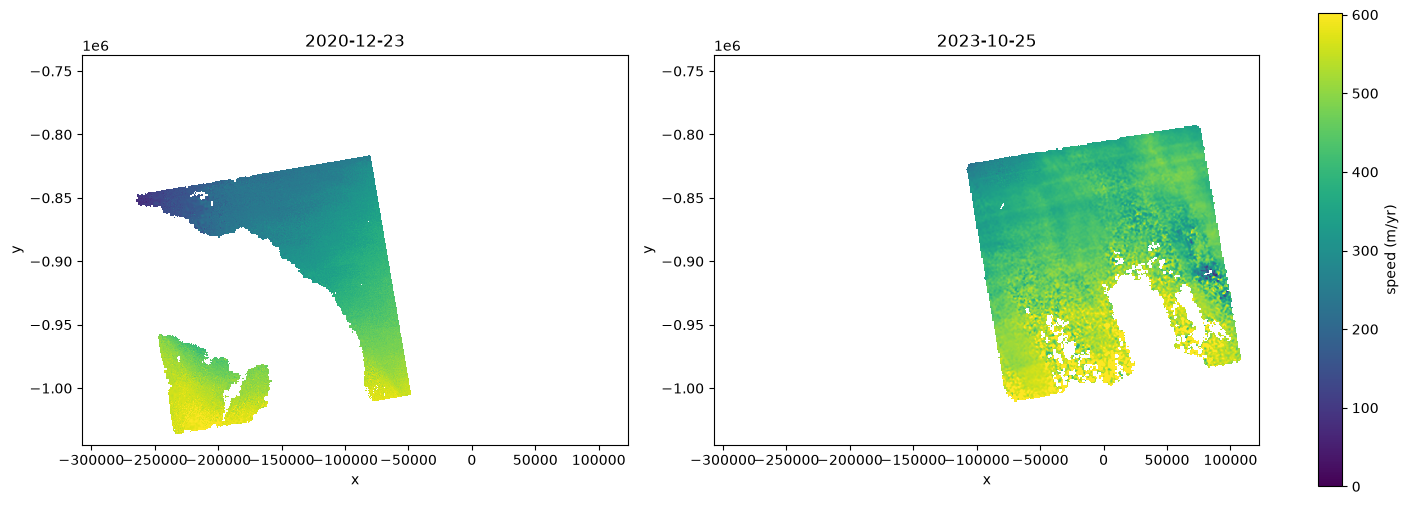

In [15]:
import matplotlib.pyplot as plt

# surface speed `v` at each time step, on a shared color scale
v = cube_roundtrip["v"].load()
vmax = float(np.nanpercentile(v, 98))

nt = v.sizes["time"]
fig, axes = plt.subplots(1, nt, figsize=(7 * nt, 6), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, t in zip(axes, range(nt)):
    im = v.isel(time=t).plot.imshow(
        ax=ax, cmap="viridis", vmin=0, vmax=vmax, add_colorbar=False
    )
    ax.set_aspect("equal")
    ax.set_title(str(v["time"].values[t])[:10])
fig.colorbar(im, ax=list(axes), label="speed (m/yr)", shrink=0.8)
plt.show()

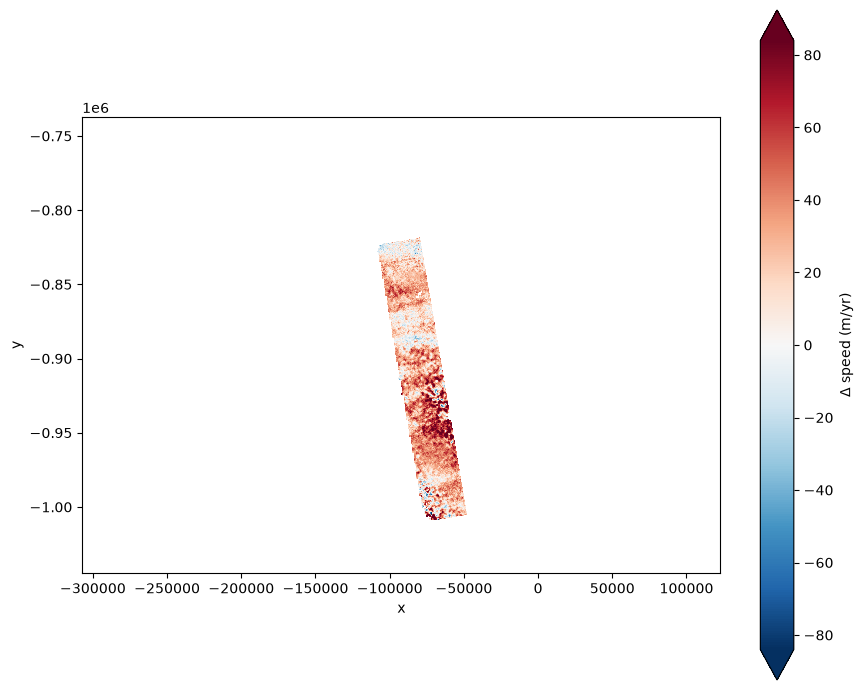

In [16]:
import matplotlib.pyplot as plt
lim = np.nanpercentile(np.abs(dv), 98)

# plot
fig, ax = plt.subplots(figsize=(9, 7))
dv.plot.imshow(
    ax=ax,
    cmap="RdBu_r",          # red = speedup, blue = slowdown
    vmin=-lim, vmax=lim,    # symmetric, centered on zero
    cbar_kwargs={"label": "Δ speed (m/yr)"},
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()